# Automated Feature Selection


## Benefits of Feature Selection

Favor simplicity by using fewer features to enhance model interpretability.

Reduce the risk of overfitting to improve generalization on new data.

Avoid multicollinearity to ensure stable and reliable model estimates.

Exclude irrelevant or uninformative features that could negatively impact certain models.

Consider the impact of feature set size on training and prediction efficiency.

## Methods



* unsupervised (e.g., removing features with low variance)

* supervised, univariate, correlation with target (e.g., select $k$ best) - metric is parameterisable

* multivariate
    - RFE (Recursive Feature Elimination)
    - From Model (e.g., feature importance based)
    - SFS (Sequential Feature Selection)


## Import Packages and Set Up Environment

In [ ]:
# !pip install -q shap

In [ ]:
import sklearn
sklearn.set_config(transform_output="pandas")

%config InlineBackend.figure_format = 'retina'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) }, style='ticks', color_codes=True, font_scale=0.8
)

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.metrics import mean_absolute_error

import shap
shap.initjs()

In [ ]:
from sklearn.datasets import make_regression

Synthetic Dataset

In [ ]:
X, y = make_regression(
    n_samples=200,
    n_features=10,
    n_informative=7,
    noise=0.2,
    effective_rank=4,
    random_state=42
)
#Making a dataset with 10 features and 2000 rows

In [ ]:
X = pd.DataFrame(X).rename(columns=lambda x: 'x' + str(x))
X.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,-0.056711,-0.040479,-0.001992,0.048749,-0.003496,-0.003888,-0.018376,-0.057141,-0.066291,0.020132
1,0.015563,-0.132476,-0.020419,0.066564,0.044311,0.010720,0.127621,0.102073,0.067242,-0.060032
2,0.023726,-0.001814,0.010952,0.071639,0.013104,0.076464,0.060048,0.040878,0.104568,-0.030093
3,-0.002274,0.097474,0.001153,-0.030261,0.030729,-0.099788,0.004121,-0.013760,-0.041493,-0.031670
4,-0.003701,-0.031351,-0.045230,0.084394,0.060211,-0.033222,0.048933,-0.056874,-0.114203,0.004870


In [ ]:
y = pd.Series(y).rename('target')
y.head()

,target
0,-9.403197
1,10.511787
2,15.548426
3,3.659229
4,0.809514


In [ ]:
data = pd.concat([X,y], axis='columns')
data.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,target
0,-0.056711,-0.040479,-0.001992,0.048749,-0.003496,-0.003888,-0.018376,-0.057141,-0.066291,0.020132,-9.403197
1,0.015563,-0.132476,-0.020419,0.066564,0.044311,0.010720,0.127621,0.102073,0.067242,-0.060032,10.511787
2,0.023726,-0.001814,0.010952,0.071639,0.013104,0.076464,0.060048,0.040878,0.104568,-0.030093,15.548426
3,-0.002274,0.097474,0.001153,-0.030261,0.030729,-0.099788,0.004121,-0.013760,-0.041493,-0.031670,3.659229
4,-0.003701,-0.031351,-0.045230,0.084394,0.060211,-0.033222,0.048933,-0.056874,-0.114203,0.004870,0.809514


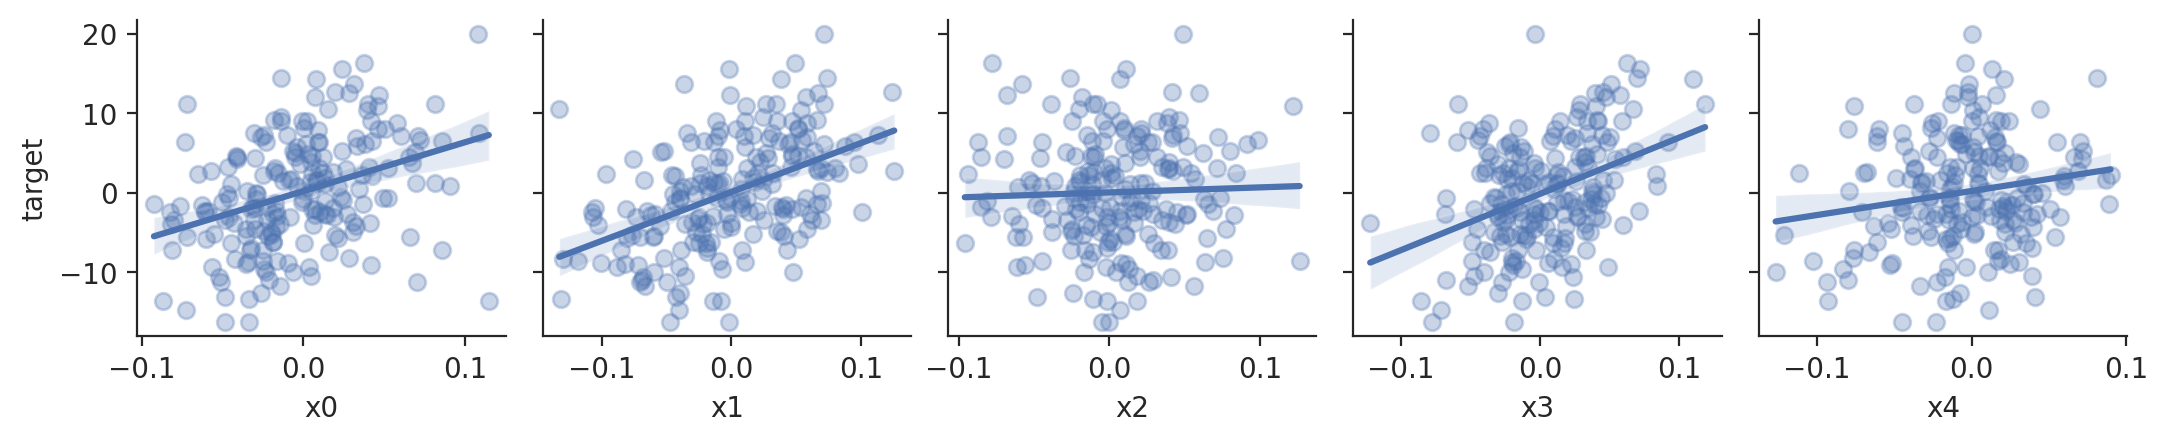

In [ ]:
sns.pairplot(
    data=data, x_vars=['x0','x1','x2','x3','x4'], y_vars='target',
    kind='reg', plot_kws=dict(scatter_kws=(dict(alpha=0.3))),
    height=2.2
);

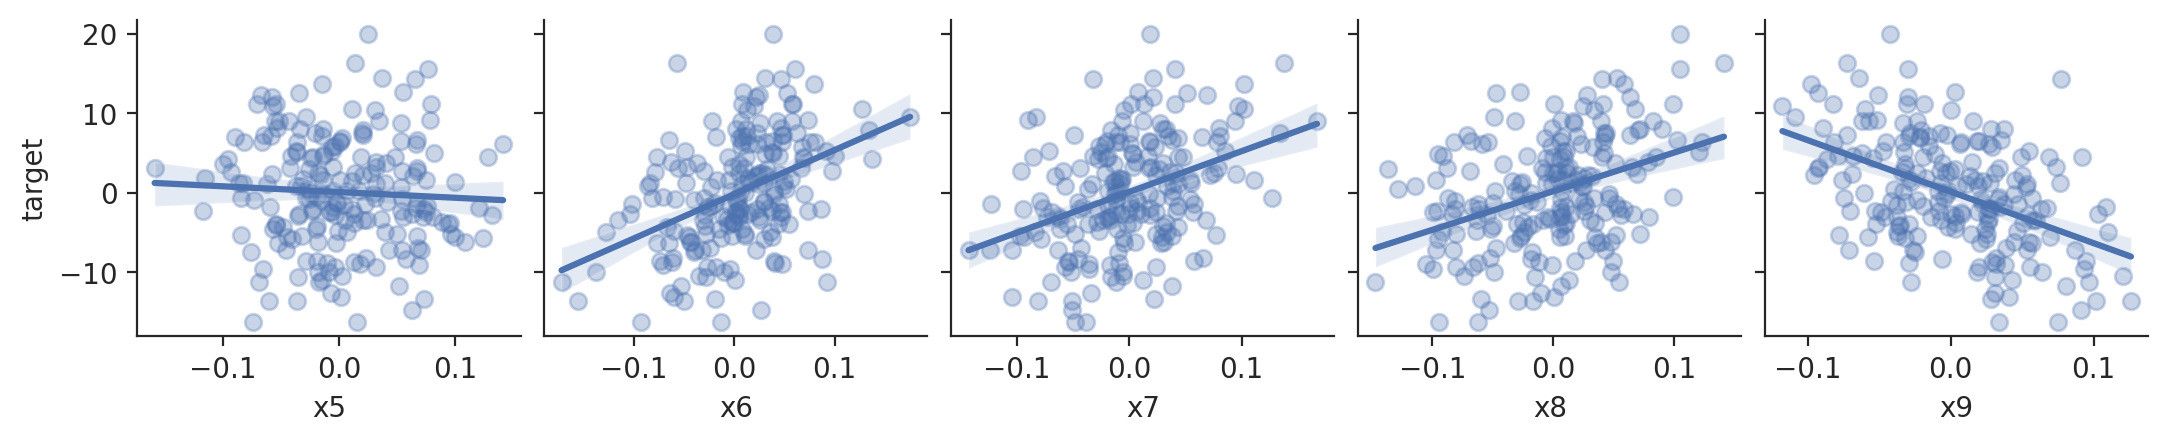

In [ ]:
sns.pairplot(
    data=data, x_vars=['x5','x6','x7','x8','x9'], y_vars='target',
    height=2.2, kind='reg', plot_kws=dict(scatter_kws=(dict(alpha=0.3)))
);

* **Features that show little correlation (x2, x5) most appropriate to be removed**

### Automated Feature Selection (AFS): Univariate

* Supervised, univariate, **relationship with target**
    - Instead of doing this manually via Exploratory Data Analysis, can be done automatically
    - This is a univariate method—features that are only important through interactions with other features may not be identified.
    - SelectKBest

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
selector = SelectKBest(f_regression, k=7).fit(X, y)
X_sel = selector.transform(X)

In [ ]:
X_sel.head()

,x0,x1,x3,x6,x7,x8,x9
0,-0.056711,-0.040479,0.048749,-0.018376,-0.057141,-0.066291,0.020132
1,0.015563,-0.132476,0.066564,0.127621,0.102073,0.067242,-0.060032
2,0.023726,-0.001814,0.071639,0.060048,0.040878,0.104568,-0.030093
3,-0.002274,0.097474,-0.030261,0.004121,-0.013760,-0.041493,-0.031670
4,-0.003701,-0.031351,0.084394,0.048933,-0.056874,-0.114203,0.004870


In [ ]:
selector.get_feature_names_out()

array(['x0', 'x1', 'x3', 'x6', 'x7', 'x8', 'x9'], dtype=object)

In [ ]:
model = LinearRegression().fit(X_sel, y)
scores = cross_val_score(model, X_sel, y)
scores.mean(), scores.std()

(np.float64(0.9930667909938024), np.float64(0.0018286800568360856))

In [ ]:
model = LinearRegression().fit(X, y)
scores = cross_val_score(model, X, y)
scores.mean(), scores.std()

(np.float64(0.9990205733326365), np.float64(0.0003333120332543318))

In [ ]:
#Model performs better with the best 7 features selected

### Recursive Feature Elimination (RFE)

 - Begin with all available features, train the model, assess feature importance (via coef_), remove the least important feature(s), and iterate

- will need to provide a $k$.

 RFECV, where the best $k$ is obtained for you based on cross-validation scores.

In [ ]:
from sklearn.feature_selection import RFECV

In [ ]:
model = LinearRegression()
rfe_selector = RFECV(model, step=1, cv=5)

In [ ]:
rfe_selector.fit(X, y)

RFECV(cv=5, estimator=LinearRegression())

In [ ]:
X_sel = rfe_selector.transform(X)
X_sel.head()

,x0,x1,x3,x4,x6,x7,x8
0,-0.056711,-0.040479,0.048749,-0.003496,-0.018376,-0.057141,-0.066291
1,0.015563,-0.132476,0.066564,0.044311,0.127621,0.102073,0.067242
2,0.023726,-0.001814,0.071639,0.013104,0.060048,0.040878,0.104568
3,-0.002274,0.097474,-0.030261,0.030729,0.004121,-0.013760,-0.041493
4,-0.003701,-0.031351,0.084394,0.060211,0.048933,-0.056874,-0.114203


In [ ]:
rfe_selector.get_feature_names_out()

array(['x0', 'x1', 'x3', 'x4', 'x6', 'x7', 'x8'], dtype=object)

In [ ]:
n_scores = len(rfe_selector.cv_results_["mean_test_score"])
n_scores

10

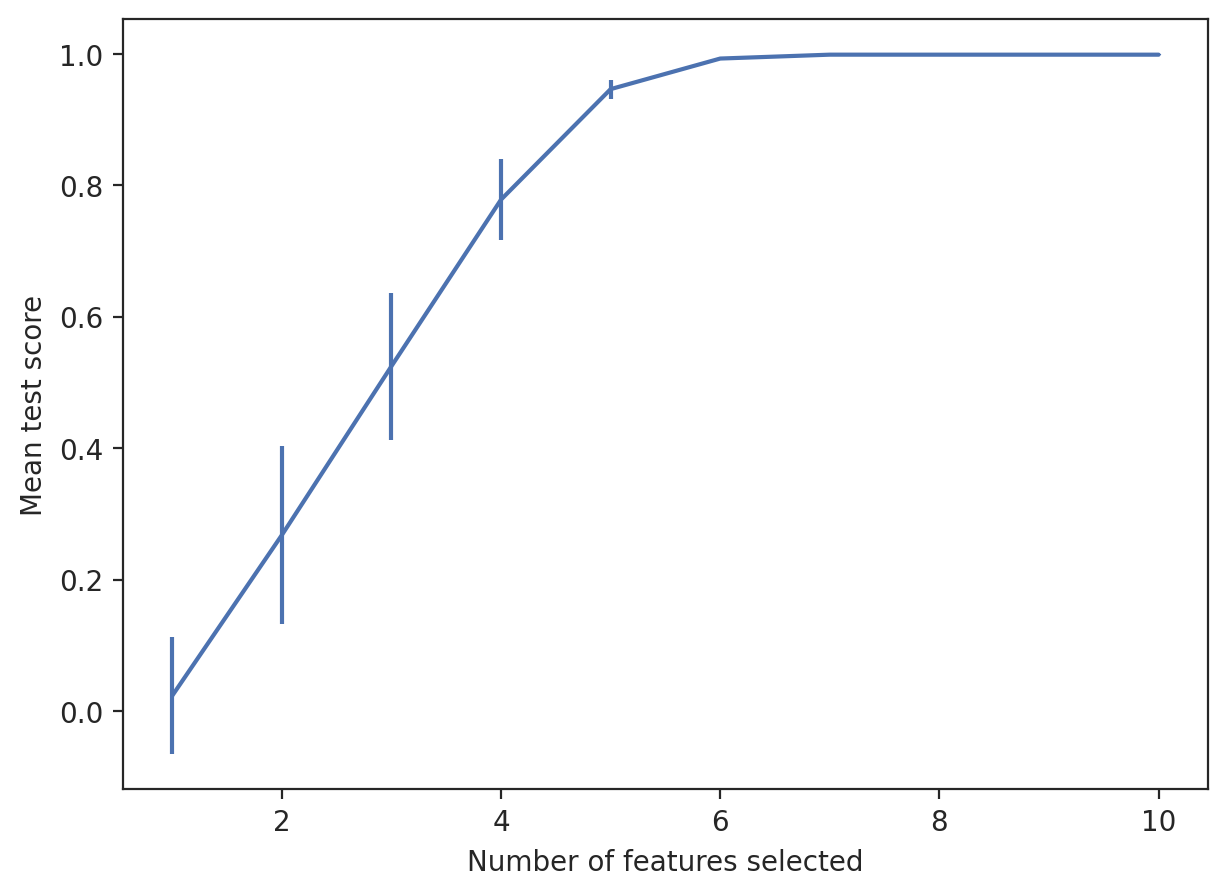

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(
    range(1, n_scores+1),
    rfe_selector.cv_results_["mean_test_score"],
    yerr=rfe_selector.cv_results_["std_test_score"],
)
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Mean test score");

In [ ]:
rfe_selector.ranking_

array([1, 1, 3, 1, 1, 4, 1, 1, 1, 2])

In [ ]:
np.argsort(rfe_selector.ranking_)

array([0, 1, 3, 4, 7, 6, 8, 9, 2, 5])

In [ ]:
np.flip(np.argsort(rfe_selector.ranking_))

array([5, 2, 9, 8, 6, 7, 4, 3, 1, 0])

In [ ]:
rfe_selector.feature_names_in_[ np.flip(np.argsort(rfe_selector.ranking_)) ]

array(['x5', 'x2', 'x9', 'x8', 'x6', 'x7', 'x4', 'x3', 'x1', 'x0'],
      dtype=object)

### Sequential Feature Selection (SFS) (Forward/Backward)

- Comprehensive search - Computaationally intensive vs SelectKBest
-Forward-SFS begins with no features selected. It identifies the single feature that, when used alone, gives the best cross-validated performance for a given model. Then, it repeatedly adds one feature at a time—the one that improves performance the most when combined with the already selected features. This process continues until the desired number of features is selected.
- difference from RFE: **model performance**
- Takes into Account feature Interactions

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

In [ ]:
sfs_forward = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select='auto', direction="forward", tol=0.05
).fit(X, y)

In [ ]:
sfs_forward.get_feature_names_out()

array(['x0', 'x1', 'x3', 'x6', 'x8', 'x9'], dtype=object)

In [ ]:
X_sel = selector.transform(X)

In [ ]:
model = LinearRegression().fit(X_sel, y)
scores = cross_val_score(model, X_sel, y)
scores.mean(), scores.std()

(np.float64(0.9930667909938024), np.float64(0.0018286800568360856))

## Example: Bike Rides dataset with Polynomial/Interaction Features

## The Bike Rides Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bike_saved.csv to bike_saved (1).csv


In [ ]:
# we decided last week that we are happy keeping most existing features as predictors,
# but we'll take out *year*, as it doesn't seem to add much when we already have
# `days_since_2011`.

In [ ]:
y = bike['cnt']
X = bike.drop(['cnt', 'yr'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=0
)

In [ ]:
X_train.head(1)

,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,days_since_2011
97,SPRING,APR,NO HOLIDAY,FRI,WORKING DAY,MISTY,7.784151,83.625,15.208464,97


### Pre-Processing

For numeric features, dealt with simply - median for missing values - and scaling/obtaining polynomial features for a linear regressor.

In [ ]:
numeric_features = X_train.select_dtypes(exclude='object').columns.tolist()
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        # ("poly_int", PolynomialFeatures(degree=2, include_bias=False))
    ]
)
print(numeric_features)
numeric_transformer

['temp', 'hum', 'windspeed', 'days_since_2011']


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())])

In [ ]:
numeric_transformer.fit_transform(X_train[numeric_features]).head()

,temp,hum,windspeed,days_since_2011
97,0.350240,0.804426,0.486058,0.132877
503,0.639257,0.355263,0.248737,0.689041
642,0.757395,0.641747,0.198020,0.879452
498,0.700435,0.431220,0.481123,0.682192
303,0.355515,0.613636,0.168555,0.415068


For categorical data, apply simple missing value imputation followed by one-hot encoding

In [ ]:
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='if_binary')),
        # ("te", TargetEncoder()),
        # ("scaler", MinMaxScaler()),
    ]
)

In [ ]:
categorical_transformer.fit_transform(X_train[categorical_features]).head()
# categorical_transformer.fit_transform(X_train[categorical_features], y_train).head()

,season_FALL,season_SPRING,season_SUMMER,season_WINTER,mnth_APR,mnth_AUG,mnth_DEC,mnth_FEB,mnth_JAN,mnth_JUL,...,weekday_MON,weekday_SAT,weekday_SUN,weekday_THU,weekday_TUE,weekday_WED,workingday_WORKING DAY,weathersit_GOOD,weathersit_MISTY,weathersit_RAIN/SNOW/STORM
97,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
503,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
642,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
498,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
303,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

### Model Fitting: with and without Feature Selection

#### Without Feature Selection

In [ ]:
regr_noFS = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regr", LinearRegression())
    ]
)

In [ ]:
regr_noFS.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['temp', 'hum', 'windspeed',
                                                   'days_since_2011']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['season', 'mnth', 'holiday',
                                                   'weekday', 'workingday',
                                                   'weathersit'])],
                                   verbose_feature_names_out=False)),
                ('regr', LinearRegression())])

In [ ]:
regr_noFS.score(X_test, y_test), regr_noFS.score(X_train, y_train)

(0.8514836056159967, 0.841492364684987)

In [ ]:
mean_absolute_error(y_test, regr_noFS.predict(X_test)), mean_absolute_error(y_train, regr_noFS.predict(X_train))

(603.0307563817294, 549.2014113388158)

In [ ]:
eval_results = cross_validate(
    regr_noFS, X_train, y_train, cv=5,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
(
    (-eval_results['test_score'].mean(), eval_results['test_score'].std(),
    -eval_results['train_score'].mean(), eval_results['train_score'].std())
)

(np.float64(583.7779255324616),
 np.float64(57.70226518584682),
 np.float64(547.6614590559441),
 np.float64(13.129238790009872))

In [ ]:
regr_noFS['preprocessor'].get_feature_names_out()

array(['temp', 'hum', 'windspeed', 'days_since_2011', 'season_FALL',
       'season_SPRING', 'season_SUMMER', 'season_WINTER', 'mnth_APR',
       'mnth_AUG', 'mnth_DEC', 'mnth_FEB', 'mnth_JAN', 'mnth_JUL',
       'mnth_JUN', 'mnth_MAR', 'mnth_MAY', 'mnth_NOV', 'mnth_OCT',
       'mnth_SEP', 'holiday_NO HOLIDAY', 'weekday_FRI', 'weekday_MON',
       'weekday_SAT', 'weekday_SUN', 'weekday_THU', 'weekday_TUE',
       'weekday_WED', 'workingday_WORKING DAY', 'weathersit_GOOD',
       'weathersit_MISTY', 'weathersit_RAIN/SNOW/STORM'], dtype=object)

In [ ]:
len(regr_noFS['preprocessor'].get_feature_names_out())

32

#### With Best-k

In [ ]:
regr_bestk = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("featsel", SelectKBest(f_regression, k=10)),
        ("regr", LinearRegression())
    ]
)

In [ ]:
regr_bestk.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['temp', 'hum', 'windspeed',
                                                   'days_since_2011']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['season', 'mnth', 'holiday',
                                                   'weekday', 'workingday',
                                                   'weathersit'])],
                                   verbose_feature_names_out=False)),
                ('featsel',
                 SelectKBest(score_func=<function f_regression at 0x7f25c9cf2480>)),
                ('regr', LinearRegression())])

In [ ]:
regr_bestk['featsel'].get_feature_names_out()

array(['temp', 'windspeed', 'days_since_2011', 'season_SUMMER',
       'season_WINTER', 'mnth_FEB', 'mnth_JAN', 'mnth_SEP',
       'weathersit_GOOD', 'weathersit_RAIN/SNOW/STORM'], dtype=object)

In [ ]:
len(regr_bestk['featsel'].get_feature_names_out())

10

In [ ]:
regr_bestk['featsel'].transform(
    regr_bestk['preprocessor'].transform(X_train)
).head()

,temp,windspeed,days_since_2011,season_SUMMER,season_WINTER,mnth_FEB,mnth_JAN,mnth_SEP,weathersit_GOOD,weathersit_RAIN/SNOW/STORM
97,0.350240,0.486058,0.132877,0.0,0.0,0.0,0.0,0.0,0.0,0.0
503,0.639257,0.248737,0.689041,0.0,0.0,0.0,0.0,0.0,1.0,0.0
642,0.757395,0.198020,0.879452,0.0,0.0,0.0,0.0,0.0,0.0,0.0
498,0.700435,0.481123,0.682192,0.0,0.0,0.0,0.0,0.0,1.0,0.0
303,0.355515,0.168555,0.415068,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
regr_bestk.score(X_test, y_test)

0.7760153174335737

In [ ]:
mean_absolute_error(y_test, regr_bestk.predict(X_test)) #performed significantly worse than with no feature selection

740.7757268702849

In [ ]:
eval_results = cross_validate(
    regr_bestk, X_train, y_train, cv=5,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
(
    (-eval_results['test_score'].mean(), eval_results['test_score'].std(),
    -eval_results['train_score'].mean(), eval_results['train_score'].std())
)

(np.float64(676.6744930267546),
 np.float64(68.46616144441388),
 np.float64(663.3263535751822),
 np.float64(17.232641485692348))

#### With RFECV

In [ ]:
regr_rfe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("featsel", RFECV(model, step=1, cv=5)),
        ("regr", LinearRegression())
    ]
)

In [ ]:
regr_rfe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['temp', 'hum', 'windspeed',
                                                   'days_since_2011']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['season', 'mnth', 'holiday',
                                                   'weekday', 'workingday',
                                                   'weathersit'])],
                                   verbose_feature_names_out=False)),
                ('featsel', RFECV(cv=5, estimator=LinearRegression())),
                ('regr', LinearRegression())])

In [ ]:
regr_rfe['featsel'].get_feature_names_out()

array(['temp', 'hum', 'windspeed', 'days_since_2011', 'season_FALL',
       'season_WINTER', 'mnth_APR', 'mnth_AUG', 'mnth_DEC', 'mnth_FEB',
       'mnth_JAN', 'mnth_JUL', 'mnth_MAR', 'mnth_MAY', 'mnth_NOV',
       'mnth_OCT', 'mnth_SEP', 'holiday_NO HOLIDAY', 'weekday_MON',
       'weekday_SUN', 'weathersit_GOOD', 'weathersit_MISTY',
       'weathersit_RAIN/SNOW/STORM'], dtype=object)

In [ ]:
len(regr_rfe['featsel'].get_feature_names_out())

23

In [ ]:
regr_rfe['featsel'].transform(
    regr_rfe['preprocessor'].transform(X_train)
).head()

,temp,hum,windspeed,days_since_2011,season_FALL,season_WINTER,mnth_APR,mnth_AUG,mnth_DEC,mnth_FEB,...,mnth_MAY,mnth_NOV,mnth_OCT,mnth_SEP,holiday_NO HOLIDAY,weekday_MON,weekday_SUN,weathersit_GOOD,weathersit_MISTY,weathersit_RAIN/SNOW/STORM
97,0.350240,0.804426,0.486058,0.132877,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
503,0.639257,0.355263,0.248737,0.689041,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
642,0.757395,0.641747,0.198020,0.879452,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
498,0.700435,0.431220,0.481123,0.682192,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
303,0.355515,0.613636,0.168555,0.415068,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
regr_rfe.score(X_test, y_test), regr_rfe.score(X_train, y_train)

(0.8517917844063306, 0.8409168618857691)

In [ ]:
mean_absolute_error(y_test, regr_rfe.predict(X_test)), mean_absolute_error(y_train, regr_rfe.predict(X_train)) #performed the best

(602.5515721653732, 551.4079857451202)

In [ ]:
eval_results = cross_validate(
    regr_rfe, X_train, y_train, cv=5,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
(
    (-eval_results['test_score'].mean(), eval_results['test_score'].std(),
    -eval_results['train_score'].mean(), eval_results['train_score'].std())
)

(np.float64(585.2021269330961),
 np.float64(57.55078761936951),
 np.float64(549.832944065065),
 np.float64(11.098682329998661))

### Extra Feature Ranking?

The fitted attributes .ranking_ and .support_ provide information about feature importance.

However, the ranking attribute assigns a rank of 1 to all features that are selected, so it doesn’t differentiate among them. In contrast, the .support_ attribute clearly indicates which features are selected, effectively distinguishing them from those that are not

In [ ]:
regr_rfe['featsel'].ranking_

array([ 1,  1,  1,  1,  1,  8,  9,  1,  1,  1,  1,  1,  1,  1,  6,  1,  1,
        1,  1,  1,  1,  4,  1,  2,  1,  5,  7, 10,  3,  1,  1,  1])

In [ ]:
X_train_tr = regr_rfe['preprocessor'].transform(X_train)

In [ ]:
X_train_tr.columns

Index(['temp', 'hum', 'windspeed', 'days_since_2011', 'season_FALL',
       'season_SPRING', 'season_SUMMER', 'season_WINTER', 'mnth_APR',
       'mnth_AUG', 'mnth_DEC', 'mnth_FEB', 'mnth_JAN', 'mnth_JUL', 'mnth_JUN',
       'mnth_MAR', 'mnth_MAY', 'mnth_NOV', 'mnth_OCT', 'mnth_SEP',
       'holiday_NO HOLIDAY', 'weekday_FRI', 'weekday_MON', 'weekday_SAT',
       'weekday_SUN', 'weekday_THU', 'weekday_TUE', 'weekday_WED',
       'workingday_WORKING DAY', 'weathersit_GOOD', 'weathersit_MISTY',
       'weathersit_RAIN/SNOW/STORM'],
      dtype='object')

In [ ]:
X_train_tr.columns[ regr_rfe['featsel'].support_ ]

Index(['temp', 'hum', 'windspeed', 'days_since_2011', 'season_FALL',
       'season_WINTER', 'mnth_APR', 'mnth_AUG', 'mnth_DEC', 'mnth_FEB',
       'mnth_JAN', 'mnth_JUL', 'mnth_MAR', 'mnth_MAY', 'mnth_NOV', 'mnth_OCT',
       'mnth_SEP', 'holiday_NO HOLIDAY', 'weekday_MON', 'weekday_SUN',
       'weathersit_GOOD', 'weathersit_MISTY', 'weathersit_RAIN/SNOW/STORM'],
      dtype='object')

In [ ]:
regr_rfe['featsel'].ranking_

array([ 1,  1,  1,  1,  1,  8,  9,  1,  1,  1,  1,  1,  1,  1,  6,  1,  1,
        1,  1,  1,  1,  4,  1,  2,  1,  5,  7, 10,  3,  1,  1,  1])

In [ ]:
regr_rfe['featsel'].ranking_.shape

(32,)

In [ ]:
np.argsort(regr_rfe['featsel'].ranking_)

array([ 0,  1,  2,  3,  4,  7,  9,  8, 12, 13, 10, 11, 15, 18, 17, 16, 30,
       29, 31, 19, 20, 22, 24, 23, 28, 21, 25, 14, 26,  5,  6, 27])

In [ ]:
X_train_tr.columns[ np.argsort(regr_rfe['featsel'].ranking_) ]

Index(['temp', 'hum', 'windspeed', 'days_since_2011', 'season_FALL',
       'season_WINTER', 'mnth_AUG', 'mnth_APR', 'mnth_JAN', 'mnth_JUL',
       'mnth_DEC', 'mnth_FEB', 'mnth_MAR', 'mnth_OCT', 'mnth_NOV', 'mnth_MAY',
       'weathersit_MISTY', 'weathersit_GOOD', 'weathersit_RAIN/SNOW/STORM',
       'mnth_SEP', 'holiday_NO HOLIDAY', 'weekday_MON', 'weekday_SUN',
       'weekday_SAT', 'workingday_WORKING DAY', 'weekday_FRI', 'weekday_THU',
       'mnth_JUN', 'weekday_TUE', 'season_SPRING', 'season_SUMMER',
       'weekday_WED'],
      dtype='object')